In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Download latest version
path = kagglehub.dataset_download("thedevastator/insurance-claim-analysis-demographic-and-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance-claim-analysis-demographic-and-health' dataset.
Path to dataset files: /kaggle/input/insurance-claim-analysis-demographic-and-health


In [2]:
import os
print(os.listdir(path))

['insurance_data.csv']


In [3]:
df=pd.read_csv(f"{path}/insurance_data.csv")
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


<BarContainer object of 11 artists>

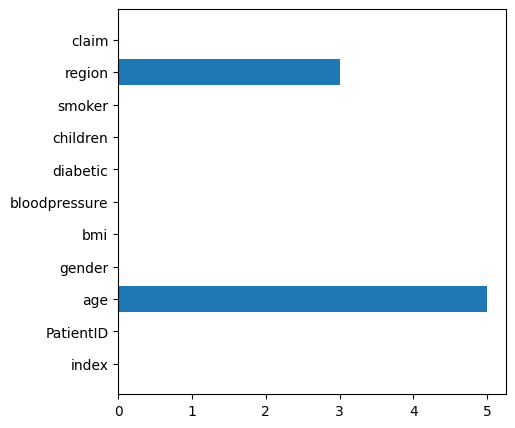

In [ ]:
fig=plt.figure(figsize=(5,5))
ax=plt.subplot()
plt.barh( df.columns,df.isna().sum())

In [4]:
df['age'] = df['age'].replace(np.nan, df['age'].sum() / (df['age'] != 0).sum())
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.000000,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.000000,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,37.936567,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,37.936567,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,37.936567,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.000000,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.000000,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.000000,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.000000,male,30.4,106,No,0,Yes,southeast,62592.87


In [5]:
df['gender'] = np.where(df['gender'] == 'male', 1, 0)
df["smoker"]=np.where(df["smoker"]=="Yes", 1,0)


In [6]:
df["diabetic"]=np.where(df["diabetic"]=="Yes", 1,0)
df["region"].value_counts()

,count
region,
southeast,443
northwest,349
southwest,314
northeast,231


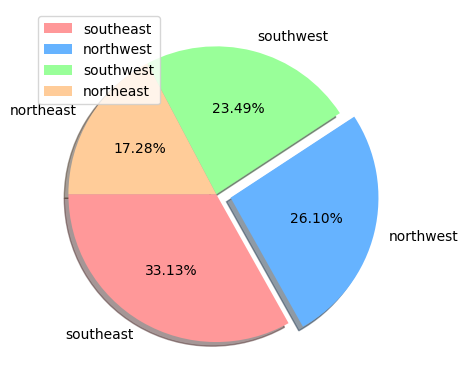

In [34]:
categories=["southeast"
,"northwest","southwest", "northeast"]
plt.pie(df["region"].value_counts(),labels=categories, autopct='%.2f%%', startangle=180, explode=[0,0.1,0,0], shadow=True, colors=['#ff9899', '#66b3ff', '#99ff99', '#ffcc99'])
plt.legend(fancybox=True, loc='upper left')
plt.show()

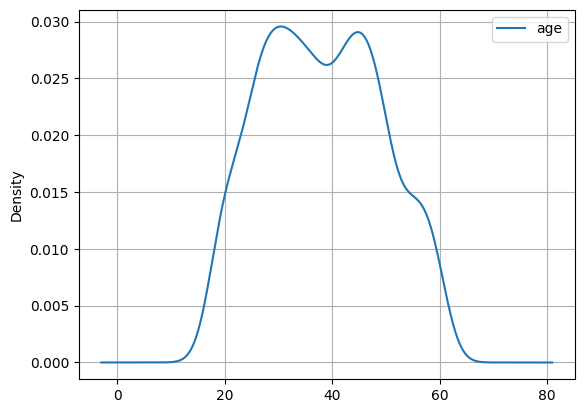

In [9]:
df["age"].plot(kind="kde", label='age')
plt.grid(True)
plt.legend()
plt.show()

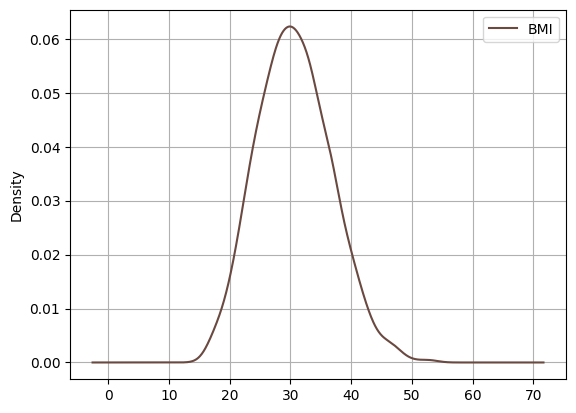

,bmi
count,1340.000000
mean,30.668955
std,6.106735
min,16.000000
25%,26.275000
50%,30.400000
75%,34.700000
max,53.100000


In [52]:
df["bmi"].describe()
df["bmi"].plot(kind='kde', label="BMI", color="#6a4941")
plt.grid(True)
plt.legend()
plt.show()
df["bmi"].describe()

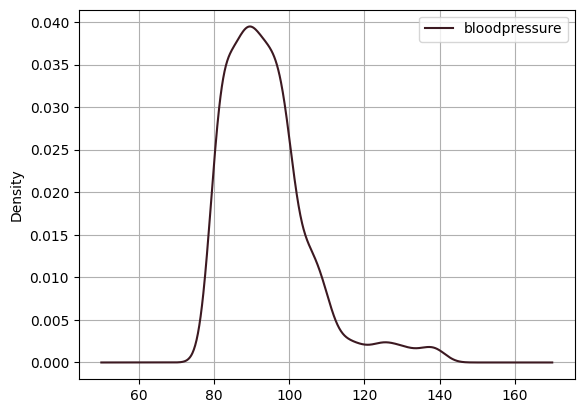

,bloodpressure
count,1340.000000
mean,94.157463
std,11.434712
min,80.000000
25%,86.000000
50%,92.000000
75%,99.000000
max,140.000000


In [ ]:
df["bloodpressure"].plot(
    kind="kde",
    label="bloodpressure",
    color="#3c1921")
plt.grid(True)
plt.legend()
plt.show()
df["bloodpressure"].describe()

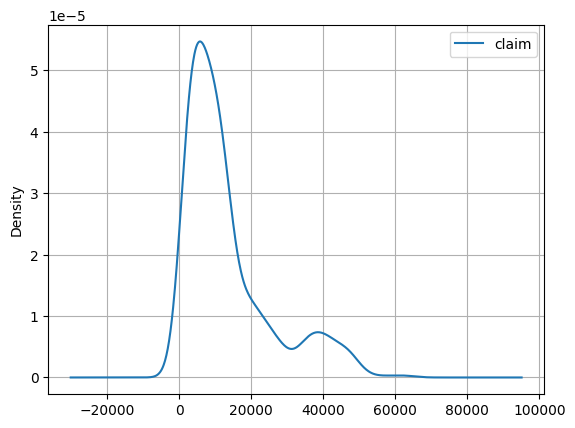

In [ ]:
df["claim"].plot(kind="kde")
plt.grid(True)
plt.legend(fancybox=True)
plt.show()

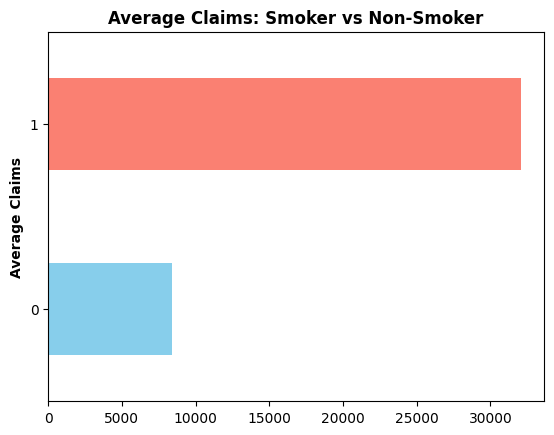

In [ ]:
df.groupby('smoker')['claim'].mean().plot(kind='barh', color=['skyblue', 'salmon'])
plt.title('Average Claims: Smoker vs Non-Smoker', fontweight="bold")
plt.ylabel('Average Claims', fontweight="bold")
plt.show()

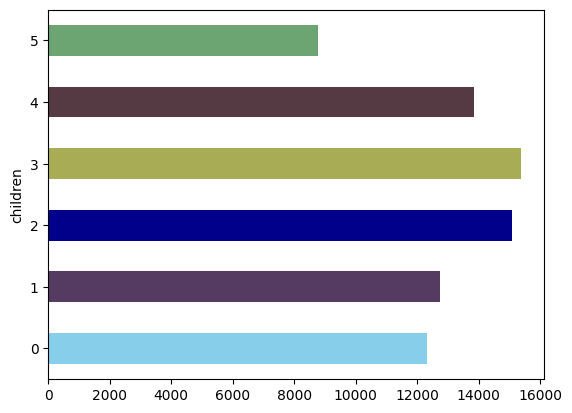

In [ ]:
df.groupby('children')['claim'].mean().plot(kind='barh', color=['skyblue', '#553b61', "darkblue", "#a8ac54","#553a44","#6da572", "#8d734c"])
plt.show()

children,0,1,2,3,4,5
smoker,,,,,,
0,80.034722,81.17284,77.083333,75.159236,88.0,94.444444
1,19.965278,18.82716,22.916667,24.840764,12.0,5.555556


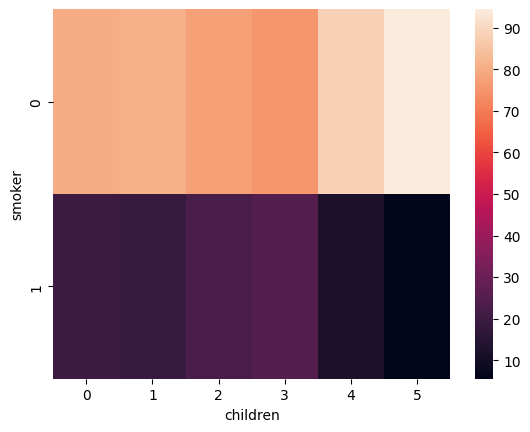

In [ ]:
import seaborn as sns
s=pd.crosstab(df["smoker"], df["children"],normalize='columns')*100
sns.heatmap(s)
s

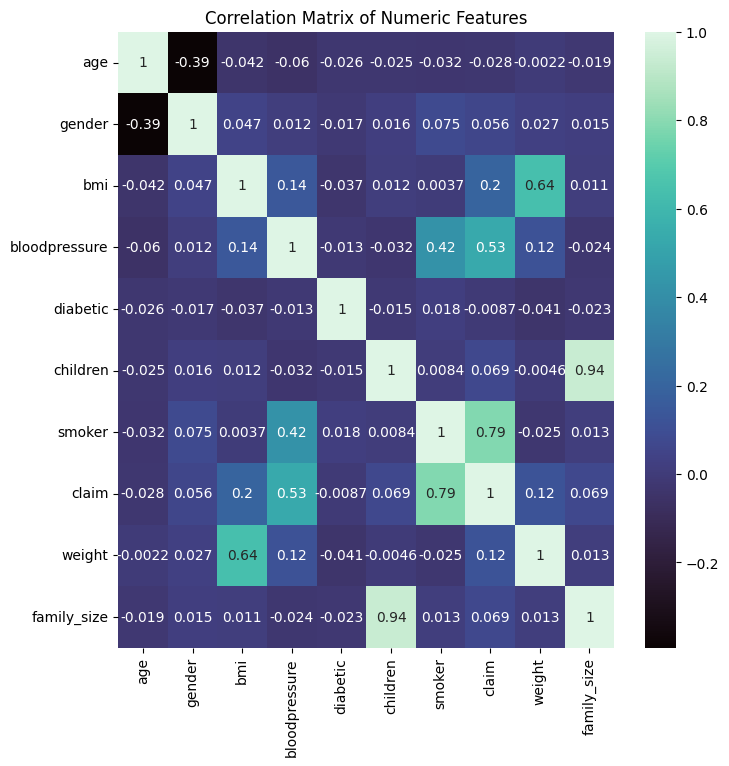

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig=plt.figure(figsize=(8,8))
df_numeric = df.drop(columns=['region', 'PatientID', 'index'])
sns.heatmap(df_numeric.corr(), annot=True, cmap='mako')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

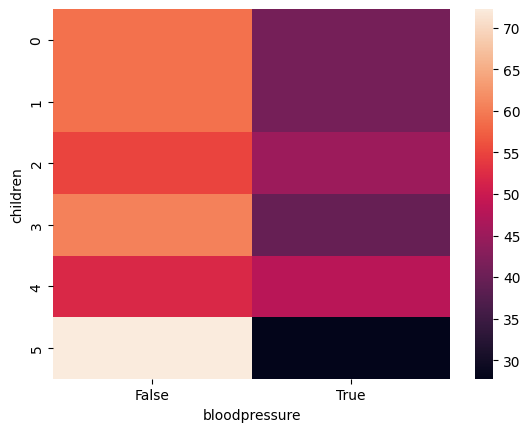

bloodpressure,False,True
children,,
0,58.854167,41.145833
1,58.950617,41.049383
2,55.000000,45.000000
3,60.509554,39.490446
4,52.000000,48.000000
5,72.222222,27.777778


In [ ]:
import seaborn as sns
sns.heatmap(pd.crosstab(df["children"], df["bloodpressure"].mean()<df["bloodpressure"], normalize='index')*100)
plt.show()
pd.crosstab(df["children"], df["bloodpressure"].mean()<df["bloodpressure"], normalize='index')*100

In [ ]:
pd.crosstab(df["children"], 120<df["bloodpressure"], normalize='index')*100

bloodpressure,False,True
children,,
0,95.312500,4.687500
1,96.604938,3.395062
2,95.833333,4.166667
3,95.541401,4.458599
4,100.000000,0.000000
5,100.000000,0.000000


In [ ]:
pd.crosstab(df["gender"], df["claim"].mean()<df["claim"],normalize="columns")

claim,False,True
gender,,
0,0.503261,0.47381
1,0.496739,0.52619


In [ ]:
pd.crosstab(df["age"]>50, df["claim"].mean()<df["claim"],normalize="index")

claim,False,True
age,,
False,0.687282,0.312718
True,0.682292,0.317708


In [ ]:
pd.crosstab(df["age"]<50, df["claim"].mean()<df["claim"],normalize="index")

claim,False,True
age,,
False,0.678571,0.321429
True,0.688172,0.311828


In [ ]:
pd.crosstab(df["children"], df["region"], normalize="index")*100

region,northeast,northwest,southeast,southwest
children,,,,
0,18.324607,26.876091,32.460733,22.338569
1,17.592593,23.456790,35.185185,23.765432
2,15.416667,27.500000,33.333333,23.750000
3,15.923567,29.299363,31.210191,23.566879
4,24.000000,24.000000,24.000000,28.000000
5,5.555556,5.555556,44.444444,44.444444


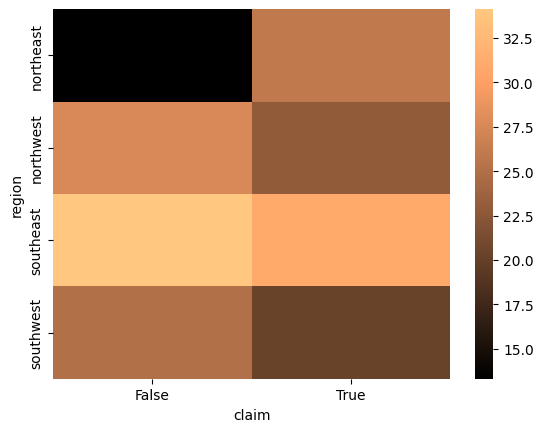

In [ ]:
import seaborn as sns
p=pd.crosstab(df["region"], df["claim"].mean()<df["claim"], normalize="columns")*100
sns.heatmap(p, cmap="copper")
plt.show()

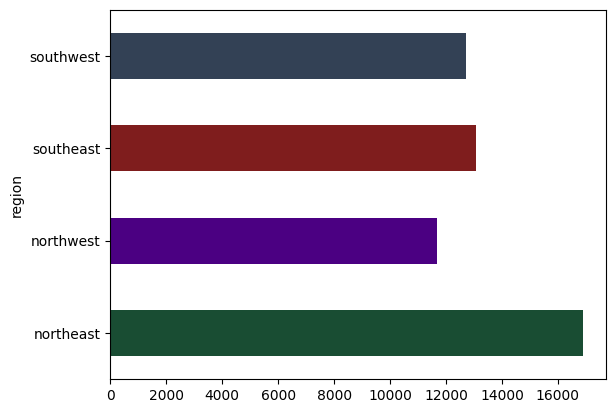

In [ ]:
df.groupby('region')['claim'].mean().plot(kind='barh', color=["#194d33", "#4b0082", "#7f1d1d", "#334155"])
plt.show()

In [7]:
def family(row):
  if row["children"]<1:
    return 0
  elif row["children"]<3:
    return 1
  else:
    return 2
df["family_size"]=df.apply(family, axis=1)
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,family_size
0,0,1,39.000000,1,23.2,91,1,0,0,southeast,1121.87,0
1,1,2,24.000000,1,30.1,87,0,0,0,southeast,1131.51,0
2,2,3,37.936567,1,33.3,82,1,0,0,southeast,1135.94,0
3,3,4,37.936567,1,33.7,80,0,0,0,northwest,1136.40,0
4,4,5,37.936567,1,34.1,100,0,0,0,northwest,1137.01,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.000000,0,35.5,88,1,0,1,northwest,55135.40,0
1336,1336,1337,59.000000,0,38.1,120,0,1,1,northeast,58571.07,1
1337,1337,1338,30.000000,1,34.5,91,1,3,1,northwest,60021.40,2
1338,1338,1339,37.000000,1,30.4,106,0,0,1,southeast,62592.87,0


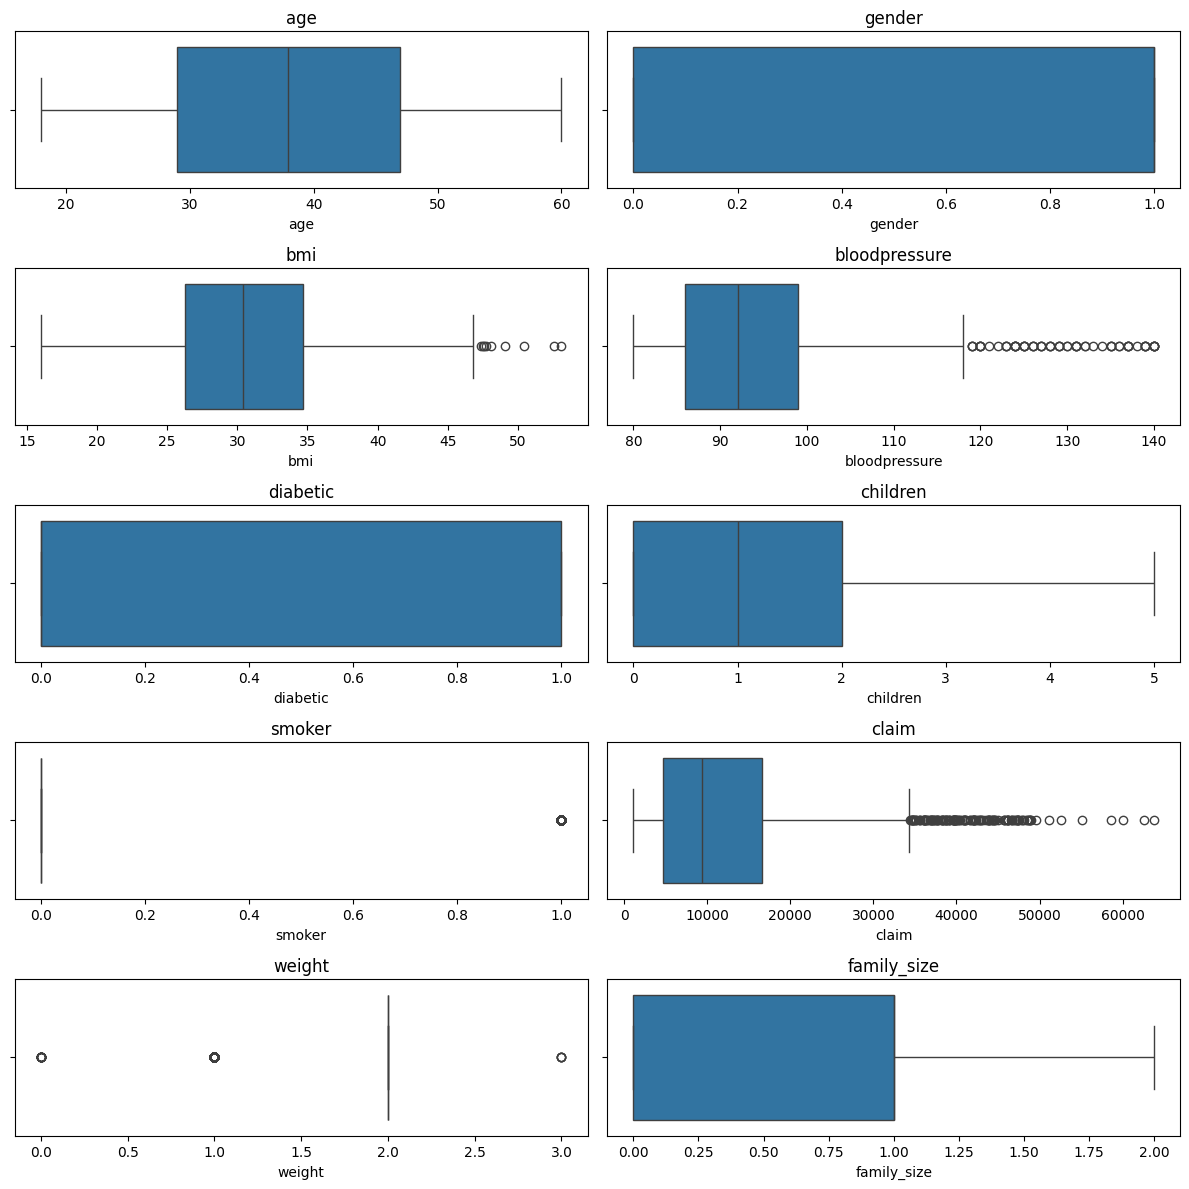

In [ ]:
fig, axes = plt.subplots(5,2, figsize=(12, 12))
df_numeric= df.drop(columns=["region", "PatientID", "index"])
for i, col in enumerate(df_numeric.columns):
    sns.boxplot(x=df[col], ax=axes.flat[i])
    axes.flat[i].set_title(col)

plt.tight_layout()
plt.show()

In [9]:
d=len(df["bloodpressure"])
z=len(df[df["bloodpressure"]>120])
print(z/d*100)
print(z,d)

4.104477611940299
55 1340


In [8]:
def weight(row):
  if row["bmi"]<18.5:
    return 0
  elif 24.9>row["bmi"]>18.5:
    return 1
  elif row["bmi"]>24.9:
    return 2
  else:
    return 3
df["weight"]=df.apply(weight, axis=1)
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,family_size,weight
0,0,1,39.000000,1,23.2,91,1,0,0,southeast,1121.87,0,1
1,1,2,24.000000,1,30.1,87,0,0,0,southeast,1131.51,0,2
2,2,3,37.936567,1,33.3,82,1,0,0,southeast,1135.94,0,2
3,3,4,37.936567,1,33.7,80,0,0,0,northwest,1136.40,0,2
4,4,5,37.936567,1,34.1,100,0,0,0,northwest,1137.01,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.000000,0,35.5,88,1,0,1,northwest,55135.40,0,2
1336,1336,1337,59.000000,0,38.1,120,0,1,1,northeast,58571.07,1,2
1337,1337,1338,30.000000,1,34.5,91,1,3,1,northwest,60021.40,2,2
1338,1338,1339,37.000000,1,30.4,106,0,0,1,southeast,62592.87,0,2


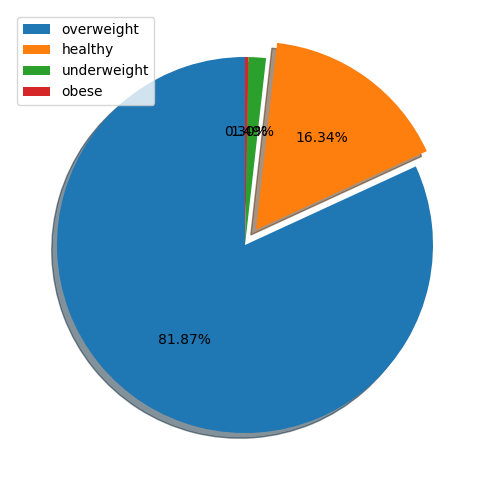

weight
2    1097
1     219
0      20
3       4
Name: count, dtype: int64


In [ ]:
fig=plt.figure(figsize=(5,5))
plt.pie(df["weight"].value_counts(), autopct="%.2f%%", shadow=True,
        explode=[0,0.1,0, 0], startangle=90, labeldistance=1.5
)
plt.legend(labels=["overweight",'healthy', "underweight", "obese"],fancybox=True, loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()
print(df["weight"].value_counts())

In [ ]:
pd.crosstab(
    pd.cut(df["age"], bins=5),
    df["weight"],
    normalize="index"
) * 100

weight,0,1,2,3
age,,,,
"(17.958, 26.4]",0.847458,15.254237,83.474576,0.423729
"(26.4, 34.8]",1.898734,17.088608,80.379747,0.632911
"(34.8, 43.2]",1.818182,16.060606,82.121212,0.000000
"(43.2, 51.6]",1.060071,16.607774,82.332155,0.000000
"(51.6, 60.0]",1.714286,16.571429,81.142857,0.571429


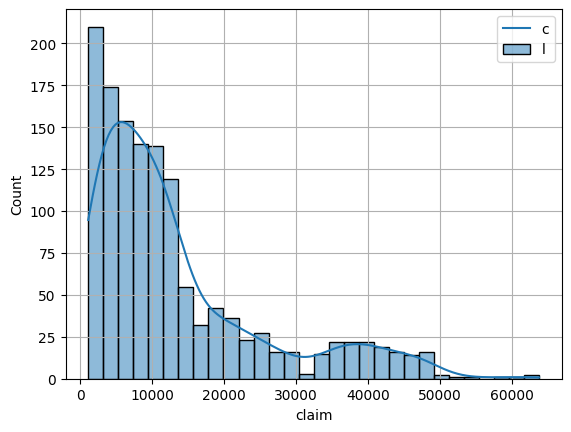

<Axes: xlabel='claim', ylabel='Density'>

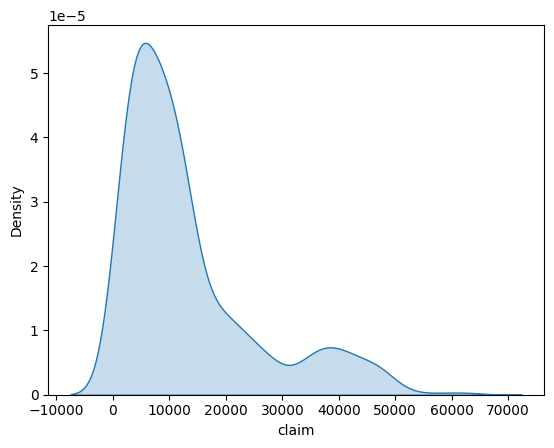

In [31]:
import seaborn as sns
sns.histplot(data=df, x="claim", fill=True, kde=True)
plt.grid(True)
plt.legend(labels="claim")
plt.show()
sns.kdeplot(data=df, x="claim", fill=True)

In [11]:
sd=df.groupby("region")
sd["claim"].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,231.0,16889.044719,11578.101476,1694.80,9521.1350,13129.600,21715.6350,58571.07
northwest,349.0,11672.088453,11031.744657,1136.40,4032.2400,8116.270,14254.6100,60021.40
southeast,443.0,13058.522664,13177.050679,1121.87,4422.0250,7358.180,17064.3050,63770.43
southwest,314.0,12723.129841,11578.518764,1261.44,5029.3775,9123.185,13839.0825,52590.83


In [9]:
DF=df.drop(columns=["bmi", "children"])
DF

,index,PatientID,age,gender,bloodpressure,diabetic,smoker,region,claim,family_size,weight
0,0,1,39.000000,1,91,1,0,southeast,1121.87,0,1
1,1,2,24.000000,1,87,0,0,southeast,1131.51,0,2
2,2,3,37.936567,1,82,1,0,southeast,1135.94,0,2
3,3,4,37.936567,1,80,0,0,northwest,1136.40,0,2
4,4,5,37.936567,1,100,0,0,northwest,1137.01,0,2
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.000000,0,88,1,1,northwest,55135.40,0,2
1336,1336,1337,59.000000,0,120,0,1,northeast,58571.07,1,2
1337,1337,1338,30.000000,1,91,1,1,northwest,60021.40,2,2
1338,1338,1339,37.000000,1,106,0,1,southeast,62592.87,0,2


In [10]:
Df = pd.get_dummies(df, columns=["region"]).astype(int)
Df.drop(columns=["index", "PatientID"], inplace=True)

In [11]:
Df

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,family_size,weight,region_northeast,region_northwest,region_southeast,region_southwest
0,39,1,23,91,1,0,0,1121,0,1,0,0,1,0
1,24,1,30,87,0,0,0,1131,0,2,0,0,1,0
2,37,1,33,82,1,0,0,1135,0,2,0,0,1,0
3,37,1,33,80,0,0,0,1136,0,2,0,1,0,0
4,37,1,34,100,0,0,0,1137,0,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,44,0,35,88,1,0,1,55135,0,2,0,1,0,0
1336,59,0,38,120,0,1,1,58571,1,2,1,0,0,0
1337,30,1,34,91,1,3,1,60021,2,2,0,1,0,0
1338,37,1,30,106,0,0,1,62592,0,2,0,0,1,0


In [12]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [13]:
x=Df.drop(columns=["claim"])
y=Df["claim"]
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker,family_size,weight,region_northeast,region_northwest,region_southeast,region_southwest
0,39,1,23,91,1,0,0,0,1,0,0,1,0
1,24,1,30,87,0,0,0,0,2,0,0,1,0
2,37,1,33,82,1,0,0,0,2,0,0,1,0
3,37,1,33,80,0,0,0,0,2,0,1,0,0
4,37,1,34,100,0,0,0,0,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,44,0,35,88,1,0,1,0,2,0,1,0,0
1336,59,0,38,120,0,1,1,1,2,1,0,0,0
1337,30,1,34,91,1,3,1,2,2,0,1,0,0
1338,37,1,30,106,0,0,1,0,2,0,0,1,0


In [15]:
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.2, random_state=292)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [22]:
model=XGBRegressor()
params = {
    "max_depth": [3, 5],
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}
Model=GridSearchCV(model, param_grid=params,cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
Model.fit(x_train, y_train)
y_pred=Model.predict(x_test)
mse=mean_squared_error(y_test, y_pred)
print(mse)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(r2, rmse)
a=mean_absolute_error(y_test, y_pred)
print(a)

24792902.0
0.8403470516204834 4979.2471318463395
3821.716064453125


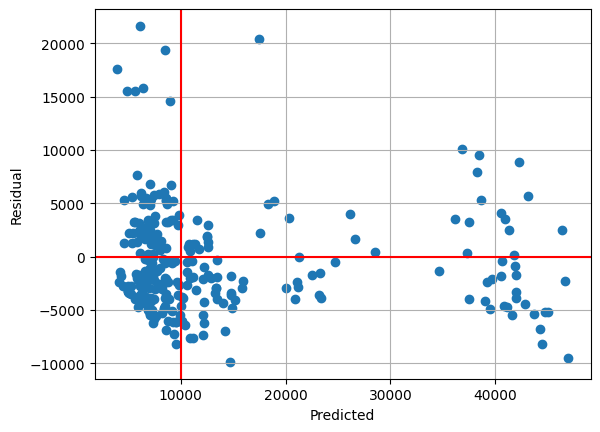

In [28]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.axvline(10000,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

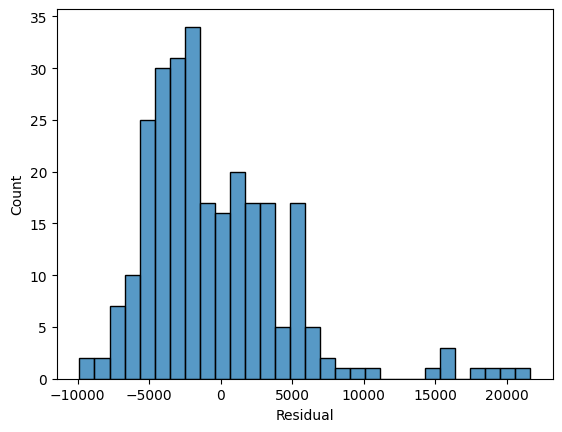

In [30]:
import seaborn as sns
sns.histplot(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [19]:
print(residuals.std())

4965.0861251383785


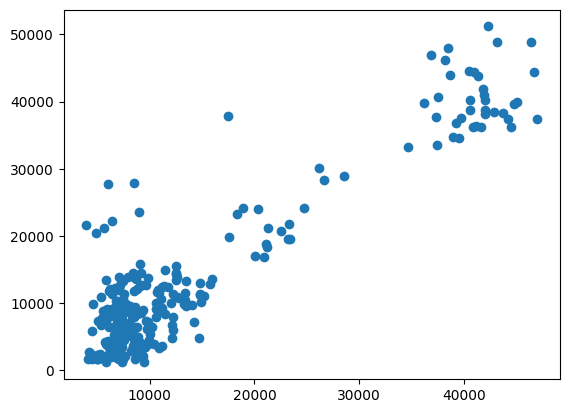

In [20]:
plt.scatter(y_pred, y_test)
plt.show()

In [24]:
print(f"{mse} is the mean squred error")
print(f"{r2}is r squared")
print(f"{rmse} is root mean squared error")
print(f"{a} is mean absolute error")

24792902.0 is the mean squred error
0.8403470516204834is r squared
4979.2471318463395 is root mean squared error
3821.716064453125 is mean absolute error


In [31]:
errors = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "residual": y_test - y_pred
})

errors.sort_values("residual", ascending=False).head(10)

,actual,predicted,residual
1163,27724,6076.291992,21647.708008
1236,37829,17440.587891,20388.412109
1165,27941,8545.287109,19395.712891
1092,21595,3953.263428,17641.736572
1102,22192,6377.707031,15814.292969
1074,20420,4845.795898,15574.204102
1087,21232,5672.443359,15559.556641
1118,23563,8987.225586,14575.774414
1314,46889,36793.835938,10095.164062
1323,47928,38435.441406,9492.558594
